# Experiment 2: Effect of Reconstruction Filters

This experiment evaluates the resolution-noise tradeoff across different FBP filters: Ram-Lak, Shepp-Logan, Cosine, and Hamming.

In [1]:
import os, sys
sys.path.append(os.path.abspath("../src"))
import numpy as np
import matplotlib.pyplot as plt
from phantom import generate_qa_phantom
from forward_projection import generate_sinogram
from fbp import reconstruct_fbp, AVAILABLE_FILTERS
from mtf import compute_mtf_from_reconstruction
from nps import compute_nps
from utils import display_images_grid, plot_mtf_curves, plot_nps_curves
os.makedirs("../results", exist_ok=True)

## 1. Generate QA Phantom and Sinogram

In [2]:
phantom, metadata = generate_qa_phantom(size=256)
num_angles = 360
sinogram, angles = generate_sinogram(phantom, num_angles)

## 2. Reconstruct with all filters

In [3]:
recons = {}
for filt in AVAILABLE_FILTERS:
    print(f"Reconstructing with {filt}...")
    recons[filt] = reconstruct_fbp(sinogram, angles, filter_name=filt)

Reconstructing with ram-lak...


Reconstructing with shepp-logan...


Reconstructing with cosine...


Reconstructing with hamming...


## 3. Visual Comparison

Saved: ../results/exp2_filters_visual.png


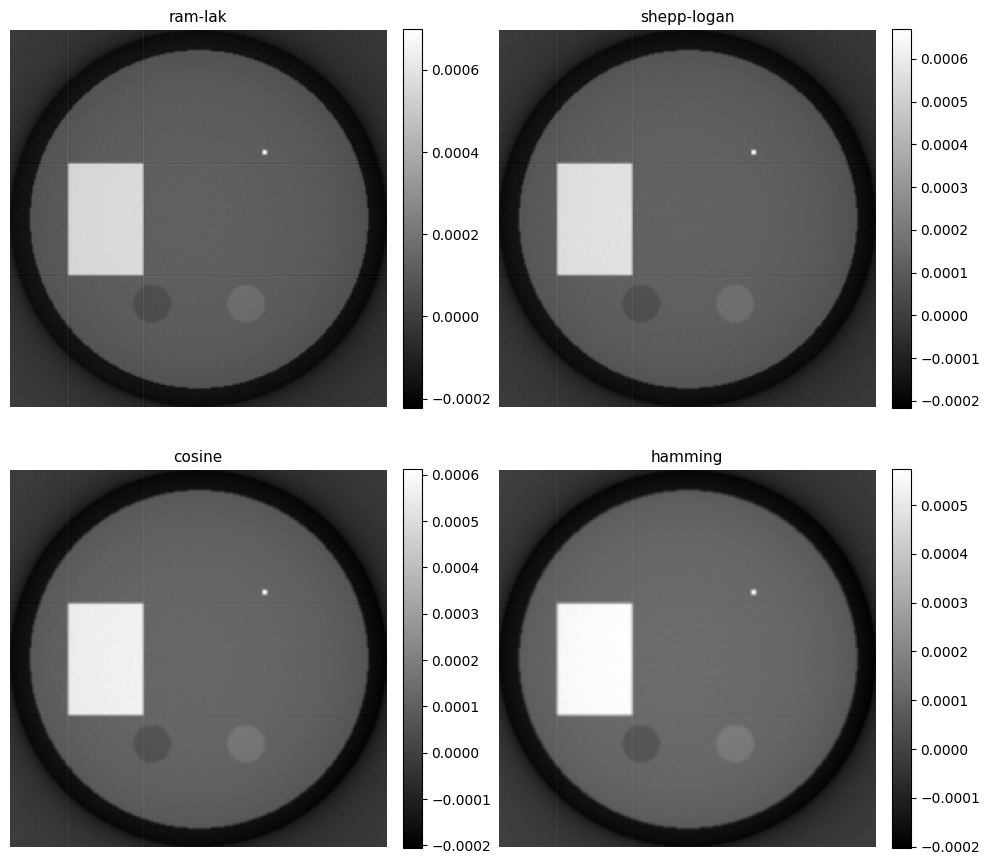

In [4]:
display_images_grid([recons[f] for f in AVAILABLE_FILTERS], titles=AVAILABLE_FILTERS, ncols=2, save_path="../results/exp2_filters_visual.png")

## 4. MTF (Spatial Resolution) and NPS (Noise Texture) Analysis

In [5]:
mtf_results = {}
nps_results = {}

for filt in AVAILABLE_FILTERS:
    recon = recons[filt]
    # MTF
    freq_mtf, mtf_vals = compute_mtf_from_reconstruction(recon, method="edge")
    mtf_results[filt] = (freq_mtf, mtf_vals)
    # NPS
    center_norm = metadata["uniform_roi"]["center_norm"]
    freq_nps, nps_vals, _, _ = compute_nps(recon, roi_size=32, num_rois=8, center=(128,128))
    nps_results[filt] = (freq_nps, nps_vals)

Saved: ../results/exp2_mtf.png


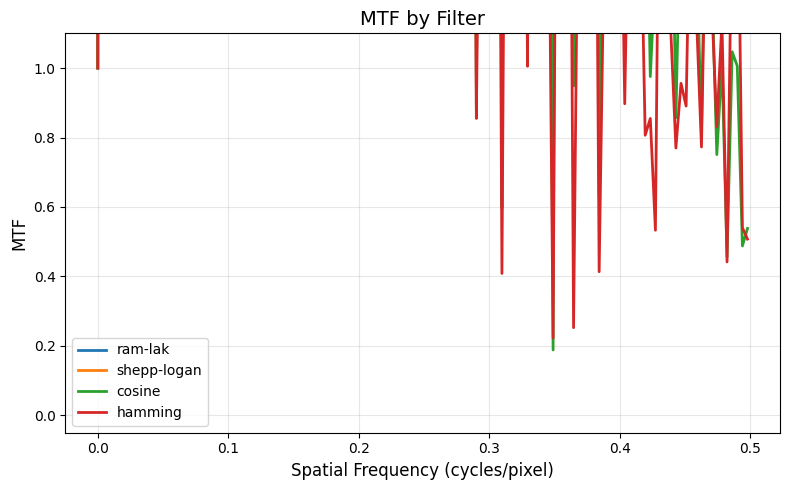

Saved: ../results/exp2_nps.png


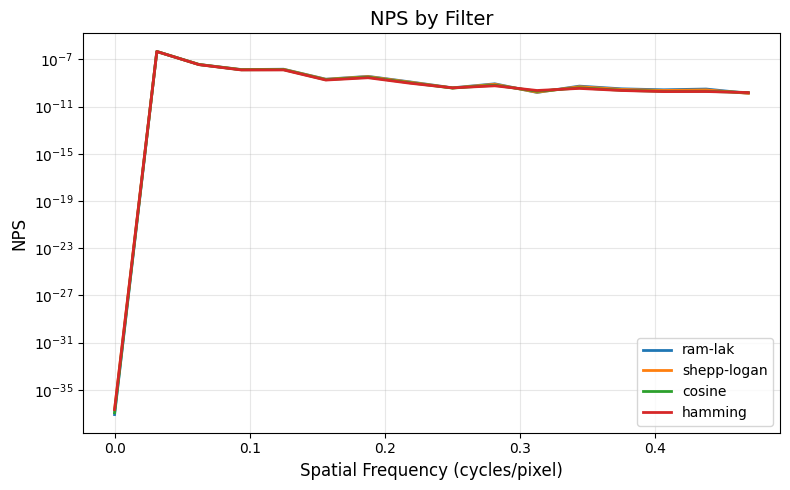

In [6]:
plot_mtf_curves(mtf_results, title="MTF by Filter", save_path="../results/exp2_mtf.png")
plot_nps_curves(nps_results, title="NPS by Filter", save_path="../results/exp2_nps.png")